<a href="https://colab.research.google.com/github/aryakumar2606/House-Price-EDA/blob/main/House_Price_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

np.random.seed(42)

print("Setup Complete")

Setup Complete


In [ ]:
# Load Dataset

df = pd.read_csv("/content/kc_house_data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
print("Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

Shape:
(21613, 21)

First 5 Rows:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-nul

In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Column Names:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Data Types:


,0
id,int64
date,object
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64



Missing Values:


,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0



Duplicate Records:
0


In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df['sale_day'] = df['date'].dt.day

display(df[['date','sale_year','sale_month']].head())

,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


In [ ]:
cols = ['price','sqft_living','bathrooms','grade']

summary_stats = df[cols].agg([
    'mean',
    'median',
    'std',
    'var',
    'min',
    'max'
])

display(summary_stats)

print("\nMode of Grade:")
print(df['grade'].mode()[0])

,price,sqft_living,bathrooms,grade
mean,5.400881e+05,2079.899736,2.114757,7.656873
median,4.500000e+05,1910.000000,2.250000,7.000000
std,3.671272e+05,918.440897,0.770163,1.175459
var,1.347824e+11,843533.681368,0.593151,1.381703
min,7.500000e+04,290.000000,0.000000,1.000000
max,7.700000e+06,13540.000000,8.000000,13.000000



Mode of Grade:
7


In [ ]:
missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

display(missing_pct[missing_pct > 0])

,0


In [ ]:
print("Duplicate Rows:")
print(df.duplicated().sum())

print("\nUnique IDs:")
print(df['id'].nunique())

print("\nTotal Rows:")
print(len(df))

Duplicate Rows:
0

Unique IDs:
21436

Total Rows:
21613


In [ ]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540088.141767,75000.0,321950.0,450000.0,645000.0,7700000.0,367127.196483
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
sqft_lot,21613.0,15106.967566,520.0,5040.0,7618.0,10688.0,1651359.0,41420.511515
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318


In [ ]:
print(df['price'].describe())

print("\nSkewness:")
print(df['price'].skew())

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

Skewness:
4.024069144684712


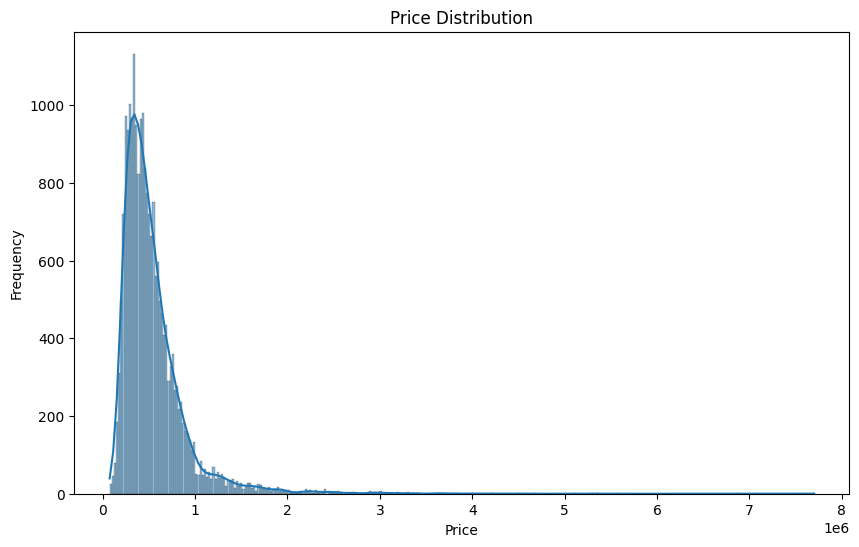

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

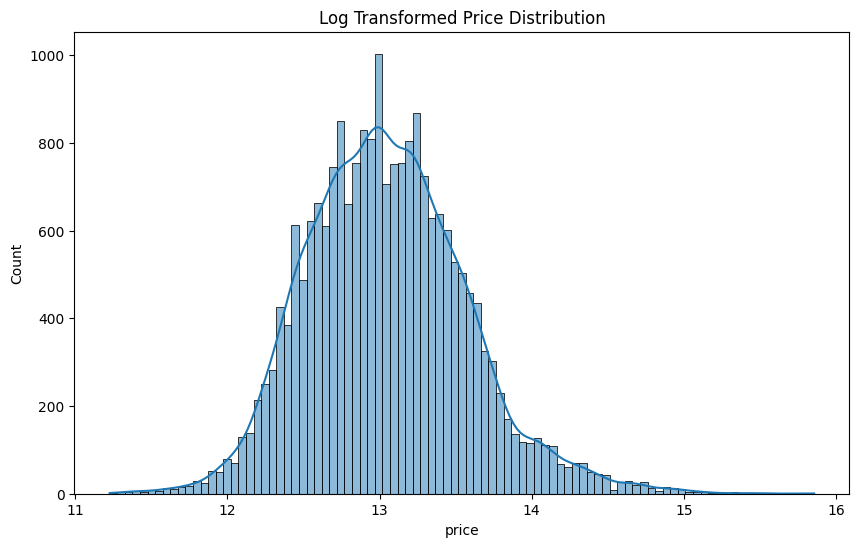

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(np.log1p(df['price']), kde=True)

plt.title("Log Transformed Price Distribution")

plt.show()

In [ ]:
corr_price = (
    df.select_dtypes(include=np.number)
      .corr()['price']
      .sort_values(ascending=False)
)

display(corr_price.head(20))

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


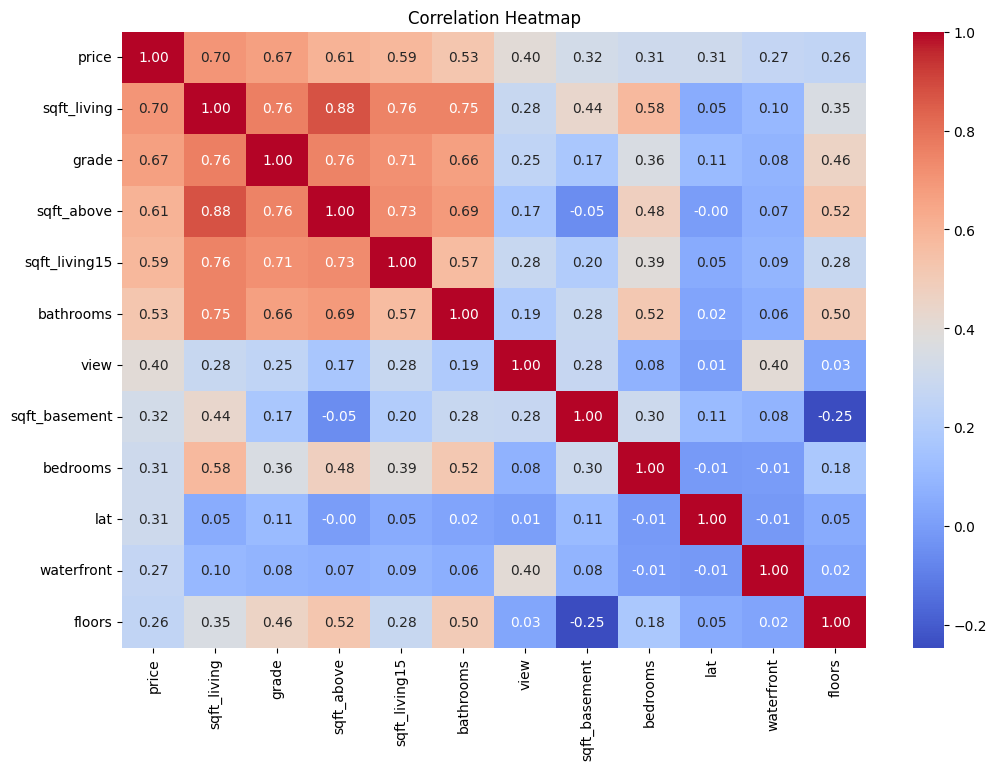

In [ ]:
top_features = corr_price.abs().sort_values(
    ascending=False
).head(12).index

plt.figure(figsize=(12,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
pair = df[['sqft_living','price']].dropna()

print("Correlation:")
print(pair.corr().loc['sqft_living','price'])

print("\nCovariance:")
print(pair.cov().loc['sqft_living','price'])

Correlation:
0.7020350546118006

Covariance:
236715431.3072001


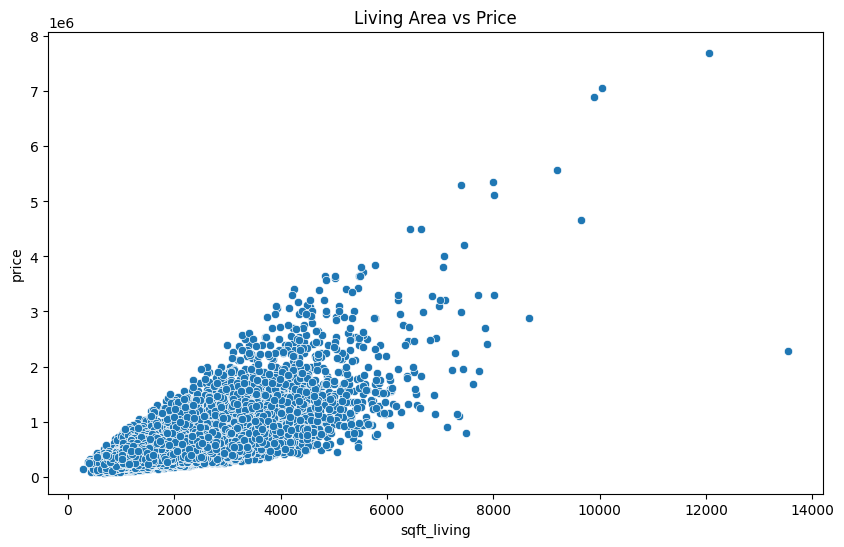

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price'
)

plt.title("Living Area vs Price")

plt.show()

In [ ]:
waterfront_summary = (
    df.groupby('waterfront')['price']
      .agg(['count','median','mean'])
)

display(waterfront_summary)

,count,median,mean
waterfront,,,
0,21450,450000.0,5.315636e+05
1,163,1400000.0,1.661876e+06


In [ ]:
grade_summary = (
    df.groupby('grade')['price']
      .agg(['count','median','mean'])
      .reset_index()
)

display(grade_summary)

,grade,count,median,mean
0,1,1,142000.0,1.420000e+05
1,3,3,262000.0,2.056667e+05
2,4,29,205000.0,2.143810e+05
3,5,242,228700.0,2.485240e+05
4,6,2038,275276.5,3.019196e+05
5,7,8981,375000.0,4.025903e+05
6,8,6068,510000.0,5.428528e+05
7,9,2615,720000.0,7.735132e+05
8,10,1134,914327.0,1.071771e+06
9,11,399,1284000.0,1.496842e+06


In [ ]:
condition_summary = (
    df.groupby('condition')['price']
      .agg(['count','median','mean'])
)

display(condition_summary)

,count,median,mean
condition,,,
1,30,262500.0,334431.666667
2,172,279000.0,327287.145349
3,14031,450000.0,542012.578148
4,5679,440000.0,521200.390033
5,1701,526000.0,612418.089359


,price
sale_month,
1,438500.0
2,425545.0
3,450000.0
4,476500.0
5,462000.0
6,465000.0
7,465000.0
8,442100.0
9,450000.0


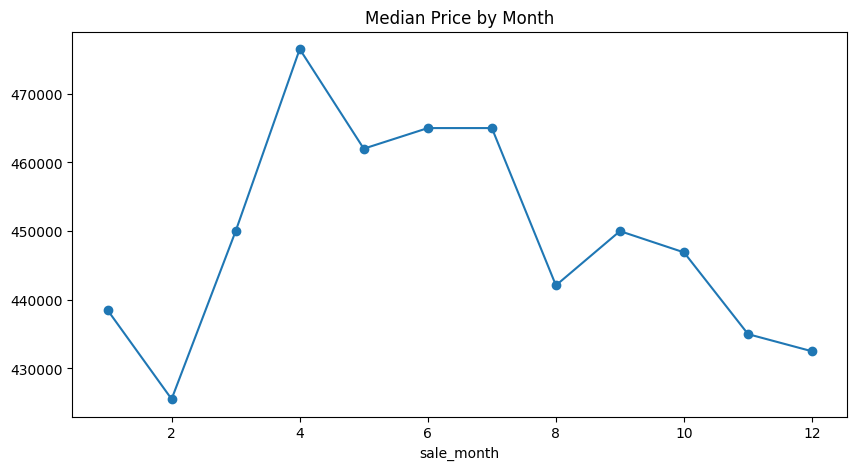

In [ ]:
monthly_price = (
    df.groupby('sale_month')['price']
      .median()
)

display(monthly_price)

plt.figure(figsize=(10,5))

monthly_price.plot(marker='o')

plt.title("Median Price by Month")

plt.show()

In [ ]:
zipcode_summary = (
    df.groupby('zipcode')['price']
      .agg(['count','median','mean'])
      .sort_values('median', ascending=False)
)

display(zipcode_summary.head(10))

,count,median,mean
zipcode,,,
98039,50,1892500.0,2.160607e+06
98004,317,1150000.0,1.355927e+06
98040,282,993750.0,1.194230e+06
98112,269,915000.0,1.095499e+06
98005,168,765475.0,8.101649e+05
98006,498,760184.5,8.596848e+05
98119,184,744975.0,8.494480e+05
98075,359,739999.0,7.905767e+05
98109,109,736000.0,8.796236e+05


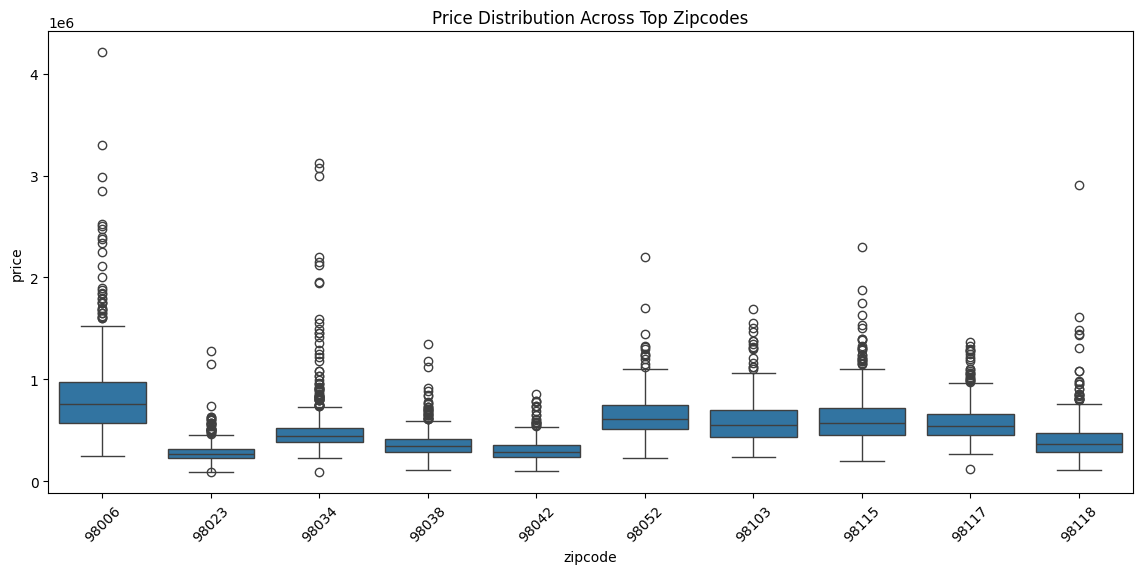

In [ ]:
top_zipcodes = (
    df['zipcode']
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[df['zipcode'].isin(top_zipcodes)],
    x='zipcode',
    y='price'
)

plt.xticks(rotation=45)

plt.title("Price Distribution Across Top Zipcodes")

plt.show()

In [ ]:
q1 = df['sqft_living'].quantile(0.25)
q3 = df['sqft_living'].quantile(0.75)

iqr = q3 - q1

outliers = df[
    (df['sqft_living'] < q1 - 1.5*iqr) |
    (df['sqft_living'] > q3 + 1.5*iqr)
]

print("Outliers Found:")
print(len(outliers))

display(outliers.head())

Outliers Found:
572


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,sale_day
5,7237550310,2014-05-12,1225000.0,4,4.50,5420,101930,1.0,0,0,...,2001,0,98053,47.6561,-122.005,4760,101930,2014,5,12
70,1525059190,2014-09-12,1040000.0,5,3.25,4770,50094,1.0,0,0,...,1973,0,98005,47.6525,-122.160,3530,38917,2014,9,12
115,3626039325,2014-11-21,740500.0,3,3.50,4380,6350,2.0,0,0,...,1900,1999,98117,47.6981,-122.368,1830,6350,2014,11,21
153,7855801670,2015-04-01,2250000.0,4,3.25,5180,19850,2.0,0,3,...,2006,0,98006,47.5620,-122.162,3160,9750,2015,4,1
239,5152100060,2014-05-29,472000.0,6,2.50,4410,14034,1.0,0,2,...,1965,0,98003,47.3376,-122.324,2600,13988,2014,5,29


In [ ]:
top_q = df['price'].quantile(0.75)

premium_prob = pd.crosstab(
    df['grade'] >= 8,
    df['price'] >= top_q,
    normalize='index'
)

display(premium_prob)

price,False,True
grade,,
False,0.934744,0.065256
True,0.546855,0.453145


In [ ]:
median_price = df['price'].median()

prob_above_median = (
    (df['price'] > median_price)
    .mean()
)

print(
    f"Probability(Home Price > Median Price): {prob_above_median:.2%}"
)

Probability(Home Price > Median Price): 49.73%


In [ ]:
temp_df = df.copy()

temp_df['price_bin'] = pd.qcut(
    temp_df['price'],
    q=5,
    duplicates='drop'
)

train_df, test_df = train_test_split(
    temp_df,
    test_size=0.20,
    random_state=42,
    stratify=temp_df['price_bin']
)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (17290, 25)
Test Shape : (4323, 25)


In [ ]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'sale_day']

Categorical Columns:
['date']


In [ ]:
missing = (
    df.isnull()
      .mean()
      .mul(100)
)

missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(8,5))
    missing.sort_values().plot(kind='barh')
    plt.title("Missing Values (%)")
    plt.show()
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


In [ ]:
print("""
PREPROCESSING PLAN

1. Target Variable:
   - price

2. Date Handling:
   - Extract year, month, day
   - Drop raw date later

3. Missing Values:
   - Median imputation for numerical columns
   - Mode imputation for categorical columns

4. Scaling:
   - StandardScaler for numerical features

5. Encoding:
   - One-Hot Encoding for categorical variables

6. Outliers:
   - Investigate extreme sqft_living and price values

7. Train-Test Split:
   - Stratified split using price bins

8. Leakage Prevention:
   - Fit all preprocessing ONLY on training data
""")


PREPROCESSING PLAN

1. Target Variable:
   - price

2. Date Handling:
   - Extract year, month, day
   - Drop raw date later

3. Missing Values:
   - Median imputation for numerical columns
   - Mode imputation for categorical columns

4. Scaling:
   - StandardScaler for numerical features

5. Encoding:
   - One-Hot Encoding for categorical variables

6. Outliers:
   - Investigate extreme sqft_living and price values

7. Train-Test Split:
   - Stratified split using price bins

8. Leakage Prevention:
   - Fit all preprocessing ONLY on training data



In [ ]:
corr_price = df.corr(numeric_only=True)['price'].sort_values(
    ascending=False
)

display(corr_price)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


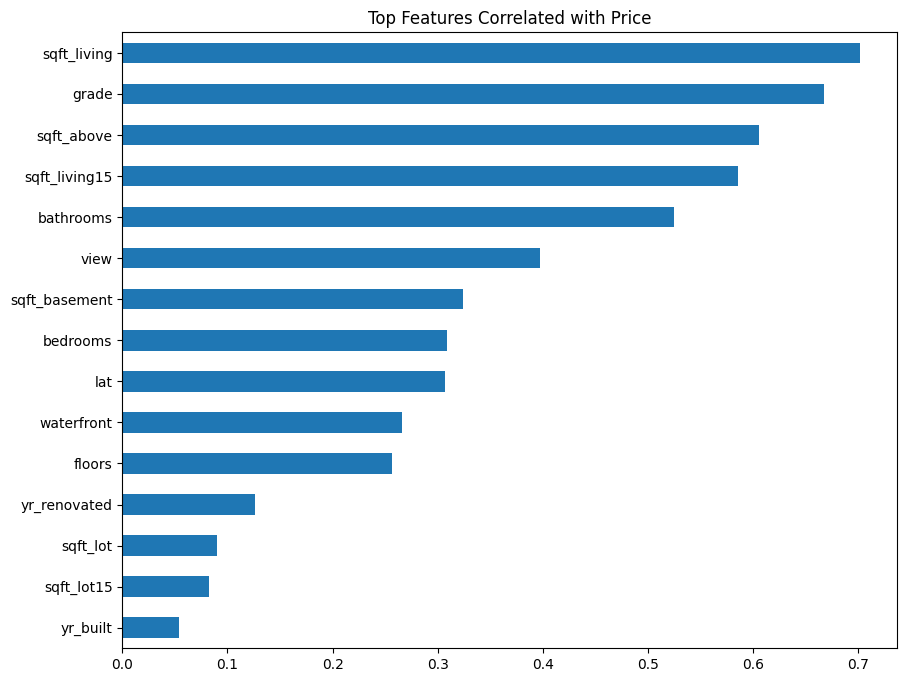

In [ ]:
plt.figure(figsize=(10,8))

corr_price.drop('price').head(15).sort_values().plot(
    kind='barh'
)

plt.title("Top Features Correlated with Price")
plt.show()

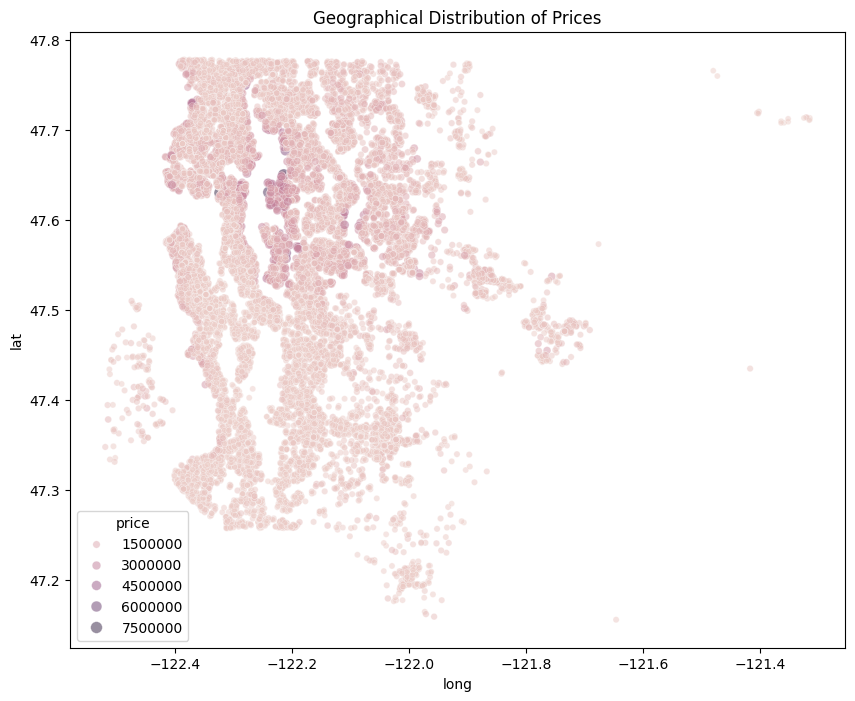

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x='long',
    y='lat',
    hue='price',
    size='price',
    alpha=0.5
)

plt.title("Geographical Distribution of Prices")
plt.show()

In [ ]:
df['house_age'] = 2015 - df['yr_built']

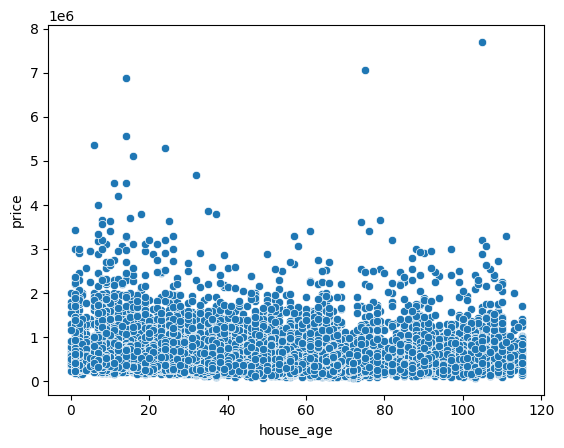

In [ ]:
sns.scatterplot(
    data=df,
    x='house_age',
    y='price'
)
plt.show()

In [ ]:
df['renovated'] = (
    df['yr_renovated'] > 0
).astype(int)

df.groupby('renovated')['price'].mean()

,price
renovated,
0,530360.818155
1,760379.029540


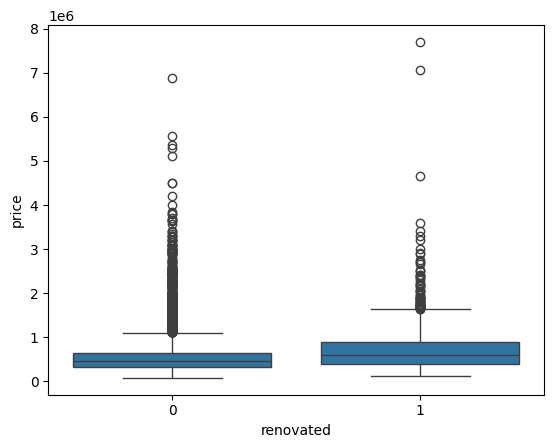

In [ ]:
sns.boxplot(
    data=df,
    x='renovated',
    y='price'
)
plt.show()

In [ ]:
df['price_per_sqft'] = (
    df['price'] / df['sqft_living']
)

In [ ]:
df['price_per_sqft'].describe()

,price_per_sqft
count,21613.000000
mean,264.156594
std,110.060793
min,87.588235
25%,182.291667
50%,244.644550
75%,318.322981
max,810.138889


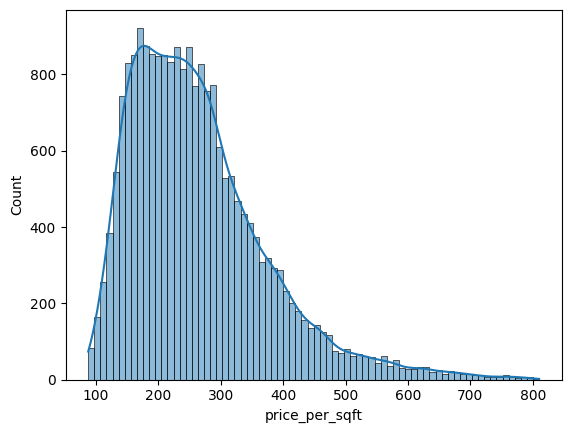

In [ ]:
sns.histplot(
    df['price_per_sqft'],
    kde=True
)
plt.show()

In [ ]:
luxury_threshold = df['price'].quantile(0.90)

df['luxury_home'] = (
    df['price'] >= luxury_threshold
)

In [ ]:
df.groupby('luxury_home').mean(
    numeric_only=True
)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,sale_day,house_age,renovated,price_per_sqft
luxury_home,,,,,,,,,,,,,,,,,,,,,
False,4.617394e+09,4.507116e+05,3.299280,2.013920,1914.545090,14178.366221,1.461388,0.002519,0.147198,3.403856,...,47.553602,-122.213555,1879.315938,12221.848226,2014.322314,6.582879,15.696401,44.358817,0.034807,250.152734
True,4.246763e+09,1.343775e+06,4.014332,3.021498,3566.791956,23457.081368,1.790337,0.052705,1.017568,3.459547,...,47.618061,-122.216963,2950.838650,17683.626445,2014.328710,6.498382,15.614424,40.722145,0.109570,390.081269


In [ ]:
waterfront_mean = df.groupby(
    'waterfront'
)['price'].mean()

premium = (
    waterfront_mean[1]
    - waterfront_mean[0]
)

print(f"Waterfront Premium: ${premium:,.0f}")

Waterfront Premium: $1,130,312


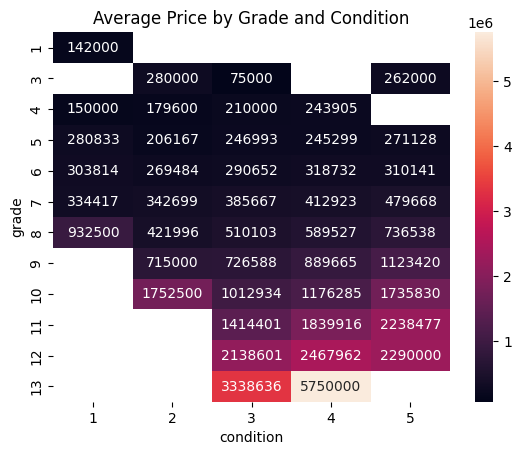

In [ ]:
pivot = pd.pivot_table(
    df,
    values='price',
    index='grade',
    columns='condition',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f'
)

plt.title(
    "Average Price by Grade and Condition"
)

plt.show()

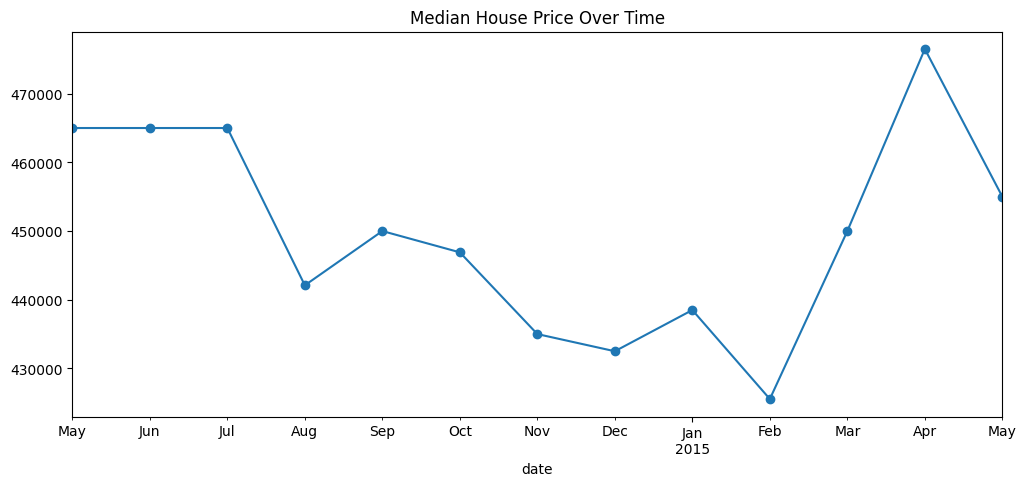

In [ ]:
monthly_price = df.groupby(
    df['date'].dt.to_period('M')
)['price'].median()

monthly_price.plot(
    figsize=(12,5),
    marker='o'
)

plt.title(
    "Median House Price Over Time"
)

plt.show()